In [16]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
import matplotlib.pyplot as plt

import json

### Read AIA results

In [17]:
# Read AIA results
with open('../tests_simulated_data/inference/runconfig.json') as file:
        runconfig = json.load(file)

# Read regression coefficients from AIA game
regCoeff = pd.read_csv("../tests_simulated_data/inference/reg_coeff_dict_keys(['x1', 'x6', 'x12']).csv")

# Parameters
d = regCoeff.shape[1] - 3
nIter = runconfig['nIter']
nSynT = runconfig['nSynT']

IMRV(weight=0.25, trunc_lvl=20)
IMRV(weight=0.5, trunc_lvl=20)
IMRV(weight=0.75, trunc_lvl=20)
CvineSensitive(lmbda=5, trunc_lvl=26)
Cvine(trunc_lvl=1)
Cvine(trunc_lvl=5)
Cvine(trunc_lvl=10)
Cvine(trunc_lvl=15)
Cvine(trunc_lvl=21)
PrivBayes(epsilon=0.1)
CTGAN(epochs=400, batch_size=100)
TVAE(epochs=800, batch_size=100)


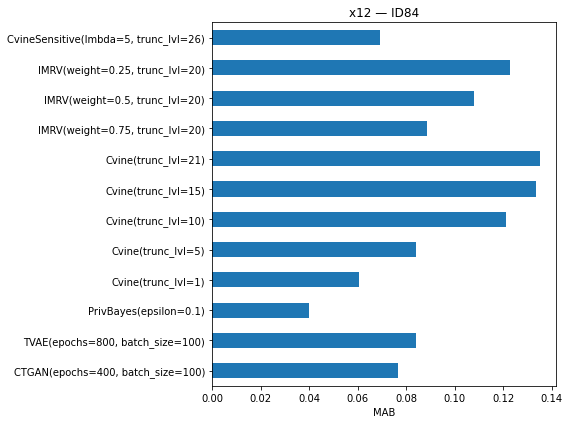

In [18]:
sa = "x12"
tid = "ID84"
MAB = []
for gm in regCoeff.genModel.unique():
    print(gm)
    df = regCoeff.loc[(regCoeff["sa"]==sa) & (regCoeff["tid"] == tid) & (regCoeff["genModel"]==gm),]
    mab = df[df.columns[range(d)]].abs().sum().sum()/(d*df.shape[0])
    MAB.append(mab)

coefficients = [f"b{i}" for i in range(d)]
MAB = regCoeff.groupby(['sa', 'tid', 'genModel'])[coefficients].apply(lambda x: x.abs().to_numpy().sum()/(d*nIter*nSynT))
MAB.name = "MAB"

sub = MAB.loc[(sa,tid)]
order = [
    'CTGAN(epochs=400, batch_size=100)',
    'TVAE(epochs=800, batch_size=100)', 
    'PrivBayes(epsilon=0.1)',
    'Cvine(trunc_lvl=1)',
    'Cvine(trunc_lvl=5)',
    'Cvine(trunc_lvl=10)',
    'Cvine(trunc_lvl=15)', 
    'Cvine(trunc_lvl=21)', 
    'IMRV(weight=0.75, trunc_lvl=20)',
    'IMRV(weight=0.5, trunc_lvl=20)',
    'IMRV(weight=0.25, trunc_lvl=20)', 
    'CvineSensitive(lmbda=5, trunc_lvl=26)',
]
sub = sub.reindex(order)
ax = sub.plot.barh(figsize=(8, 6))
ax.set_xlabel("MAB")
ax.set_ylabel("")
ax.set_title(f"{sa} — {tid}")
plt.tight_layout()
plt.show()

### Read utility results

In [19]:
with open('../tests_simulated_data/utility/utility_metrics_real_data.json') as file:
        utility_metrics = json.load(file)
utility_metrics = pd.DataFrame(utility_metrics)

### Make privacy utility plots

In [20]:
privacy_utility_df = pd.concat([utility_metrics.loc["AUC-ROC"], MAB.loc[(sa, tid)]], axis=1)

In [21]:
df = privacy_utility_df

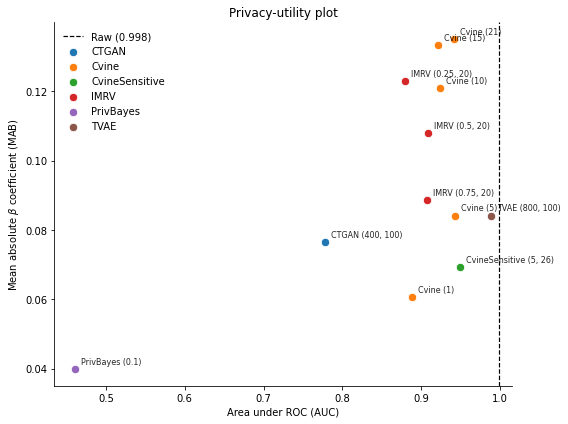

In [22]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# df: index = model names, columns = ['AUC-ROC', 'MAB']

def short_name(s):
    m = re.match(r'([^(]+)\((.*)\)', s)
    if not m:
        return s, s
    family, args = m.group(1), m.group(2)
    nums = re.findall(r'=\s*([\d.]+)', args)          # "trunc_lvl=15" -> "15"
    return family, f"{family} ({', '.join(nums)})" if nums else family

raw_auc = df.loc['Raw', 'AUC-ROC']
plot_df = df.drop(index='Raw').copy()

families, labels = zip(*[short_name(i) for i in plot_df.index])
plot_df['family'], plot_df['label'] = families, labels

fig, ax = plt.subplots(figsize=(8, 6))

palette = dict(zip(sorted(set(families)), plt.cm.tab10.colors))
for fam, sub in plot_df.groupby('family'):
    ax.scatter(sub['AUC-ROC'], sub['MAB'], s=70, color=palette[fam],
               edgecolor='white', linewidth=0.8, label=fam, zorder=3)

ax.axvline(raw_auc, color='black', linestyle='--', linewidth=1.2, zorder=2,
           label=f'Raw ({raw_auc:.3f})')

for _, r in plot_df.iterrows():
    ax.annotate(r['label'], (r['AUC-ROC'], r['MAB']),
                textcoords='offset points', xytext=(6, 5),
                fontsize=8, alpha=0.85)

ax.set_xlabel('Area under ROC (AUC)')
ax.set_ylabel(r'Mean absolute $\beta$ coefficient (MAB)')
ax.set_title('Privacy-utility plot')
ax.legend(frameon=False, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()